In [ ]:
import os, math, glob
import numpy as np
import cv2
from scipy import ndimage
from google.colab import drive

In [ ]:
drive.mount('/content/gdrive')
DATASET_DIR = '/content/gdrive/MyDrive/ZAW_lab11/pedestrians'
POSITIVE_DIR = os.path.join(DATASET_DIR, 'pos')
NEGATIVE_DIR = os.path.join(DATASET_DIR, 'neg')

Mounted at /content/gdrive


In [ ]:
#@title 1. Obliczenie gradientów (Gx, Gy → magnitude & orientation)

def compute_gradients(img: np.ndarray):
    """
    Zwraca:
        mag  – macierz amplitud gradientu  (H×W)
        ori  – macierz orientacji [0°,180°) (H×W, float32)
    Obsługuje zarówno obraz 1-kanałowy (szarości), jak i RGB.
    """
    if img.ndim == 2:      # skala szarości
        img = img.astype(np.float32)
        k = np.array([-1, 0, 1], np.float32)
        gx = ndimage.convolve1d(img, k, axis=1, mode='reflect')
        gy = ndimage.convolve1d(img, k, axis=0, mode='reflect')
        mag = np.sqrt(gx**2 + gy**2)
        ori = (np.rad2deg(np.arctan2(gy, gx)) + 180) % 180
        return mag, ori.astype(np.float32)

    # --- RGB --------------------------------------------------------------
    img = img.astype(np.float32)
    k = np.array([-1, 0, 1], np.float32)

    gx = np.stack([ndimage.convolve1d(img[:, :, c], k, axis=1, mode='reflect')
                   for c in range(3)], axis=2)
    gy = np.stack([ndimage.convolve1d(img[:, :, c], k, axis=0, mode='reflect')
                   for c in range(3)], axis=2)
    mag_all = np.sqrt(gx**2 + gy**2)

    # indeks kanału o największej amplitudzie
    max_idx = np.argmax(mag_all, axis=2)
    rows = np.arange(img.shape[0])[:, None]
    cols = np.arange(img.shape[1])[None, :]
    mag = mag_all[rows, cols, max_idx]
    gx_max = gx[rows, cols, max_idx]
    gy_max = gy[rows, cols, max_idx]

    ori = (np.rad2deg(np.arctan2(gy_max, gx_max)) + 180) % 180
    return mag.astype(np.float32), ori.astype(np.float32)


In [ ]:
def cell_histogram(mag_cell, ori_cell, bins=9):
    """
    Histogram 0–180° z interpolacją *między środkami* przedziałów.
    """
    BW = 180.0 / bins                      # 20° przy bins=9
    ori = ori_cell.ravel()
    mag = mag_cell.ravel()

    # indeks binu, do którego NALEŻY środek bliższy kątowi theta
    bin_idx = np.floor(ori / BW).astype(np.int32) % bins
    center_low = (bin_idx + 0.5) * BW      # θ_LB – środek „dolnego” binu

    # różnica od środka – dodatnia => bliżej środka bin_idx+1,
    # ujemna  => bliżej środka bin_idx-1 (z zawinięciem).
    diff = ori - center_low
    weight_hi = np.abs(diff) / BW          # υUB   lub υLB  z równania (11.4)/(11.5)
    weight_lo = 1.0 - weight_hi

    bin_hi = (bin_idx + np.sign(diff).astype(np.int32)) % bins

    hist = np.bincount(bin_idx, weights=mag * weight_lo, minlength=bins).astype(np.float32)
    hist += np.bincount(bin_hi,  weights=mag * weight_hi, minlength=bins).astype(np.float32)
    return hist


In [ ]:
#@title 3. Deskryptor HOG dla okna 64×128 (= 3780 cech)

def hog_descriptor(img,
                   cell_size=8, block_size=2,
                   bins=9, eps=1e-5):
    """
    img – obraz 64×128 (px) w RGB lub BGR (OpenCV). Zwraca wektor 3780.
    """
    if img.shape[:2] != (128, 64):
        raise ValueError('Wejściowy obraz musi mieć dokładnie 64×128 px!')

    mag, ori = compute_gradients(img)

    # --- hist  (YY_cell × XX_cell × bins) ----------------------------------
    YY_cell, XX_cell = (mag.shape[0] // cell_size,
                         mag.shape[1] // cell_size)
    hist = np.zeros((YY_cell, XX_cell, bins), np.float32)

    for j in range(YY_cell):
        for i in range(XX_cell):
            y0, y1 = j * cell_size, (j + 1) * cell_size
            x0, x1 = i * cell_size, (i + 1) * cell_size
            hist[j, i] = cell_histogram(mag[y0:y1, x0:x1],
                                        ori[y0:y1, x0:x1],
                                        bins)

    # --- normalizacja w blokach 2×2 (50 % overl.) --------------------------
    features = []
    for j in range(YY_cell - block_size + 1):
        for i in range(XX_cell - block_size + 1):
            block = hist[j:j + block_size,
                         i:i + block_size].ravel()
            norm = np.linalg.norm(block) + eps
            features.extend(block / norm)

    return np.array(features, dtype=np.float32)


In [ ]:
#@title 4. Szybki test na kontrolnym obrazku

# Ładujemy przykładowe pozytywne okno 64×128 px
test_path = sorted(glob.glob(os.path.join(POSITIVE_DIR, '*.ppm')) +
                   glob.glob(os.path.join(POSITIVE_DIR, '*.png')))[0]

img = cv2.cvtColor(cv2.imread(test_path), cv2.COLOR_BGR2RGB)
hvec = hog_descriptor(img)

print(f'Ścieżka: {test_path}')
print('Rozmiar   wektora cech :', hvec.size)                 # 3780
print('Pierwsze 10 wartości  :')
print('\n'.join([f'{v:.8f}' for v in hvec[:10]]))


Ścieżka: /content/gdrive/MyDrive/ZAW_lab11/pedestrians/pos/per00060.ppm
Rozmiar   wektora cech : 3780
Pierwsze 10 wartości  :
0.22868647
0.03915634
0.05689004
0.08442446
0.26363134
0.10678402
0.09617451
0.03551887
0.17670459
0.18710835


In [ ]:
test_path = os.path.join(POSITIVE_DIR, 'per00060.ppm')
img = cv2.cvtColor(cv2.imread(test_path), cv2.COLOR_BGR2RGB)
hvec = hog_descriptor(img)
print(hvec[:10])

[0.34383753 0.15957718 0.10338743 0.13061543 0.1425691  0.09477551
 0.08953745 0.19279516 0.1938804  0.1601409 ]


In [ ]:
#@title 0️⃣  Importy + ścieżki
import os, glob, cv2
import numpy as np
from sklearn import svm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score

In [ ]:
#@title 1️⃣  Budujemy macierz HOG_data  (200 × 3781)

# wybieramy dokładnie pierwsze 100 pozytywów i pierwsze 100 negatywów
pos_paths = sorted(glob.glob(os.path.join(POSITIVE_DIR, '*.ppm')))[:100]
neg_paths = sorted(glob.glob(os.path.join(NEGATIVE_DIR, '*.png')))[:100]

assert len(pos_paths) == 100 and len(neg_paths) == 100, "Brakuje próbek!"

HOG_data = np.zeros((200, 3781), np.float32)   # 1 kolumna = label, 3780 = cechy

# --- pozytywne ------------------------------------------------------------
for i, p in enumerate(pos_paths):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    HOG_data[i,   0]  = 1                    # etykieta 1 = pieszy
    HOG_data[i,   1:] = hog_descriptor(img) # cechy

# --- negatywne ------------------------------------------------------------
for i, p in enumerate(neg_paths, start=100):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    HOG_data[i,   0]  = 0                    # etykieta 0 = tło
    HOG_data[i,   1:] = hog_descriptor(img)

print('Gotowe – macierz HOG_data:', HOG_data.shape)

Gotowe – macierz HOG_data: (200, 3781)


In [ ]:
#@title 2️⃣  Podział na dane i etykiety
labels = HOG_data[:, 0].astype(np.int32)   # (200,)
data   = HOG_data[:, 1:]                   # (200, 3780)


In [ ]:
#@title 3️⃣  Trenowanie liniowego SVM (kernel='linear', C=1.0)
clf = svm.SVC(kernel='linear', C=1.0)      # równoważne LinearSVC dla tak małego zbioru
clf.fit(data, labels)

pred_train = clf.predict(data)
cm_train   = confusion_matrix(labels, pred_train)
acc_train  = accuracy_score(labels, pred_train)

print('=== M A C I E R Z   P O M Y Ł E K  (train) ===')
print(cm_train)
print(f'\nTrain accuracy: {acc_train*100:.2f} %')
print('\nSzczegóły:\n', classification_report(labels, pred_train, target_names=['neg', 'pos']))


=== M A C I E R Z   P O M Y Ł E K  (train) ===
[[100   0]
 [  0 100]]

Train accuracy: 100.00 %

Szczegóły:
               precision    recall  f1-score   support

         neg       1.00      1.00      1.00       100
         pos       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
#@title 4️⃣  Walidacja: podział train/test + przeszukanie najlepszego C
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.25, random_state=42, stratify=labels)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid = GridSearchCV(
    estimator=svm.LinearSVC(dual=False, max_iter=10000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1)

grid.fit(X_train, y_train)
print('\nNajlepsze C:', grid.best_params_['C'],
      ' | CV-accuracy:', grid.best_score_)

best_clf = grid.best_estimator_
y_pred   = best_clf.predict(X_test)

cm_test  = confusion_matrix(y_test, y_pred)
acc_test = accuracy_score(y_test, y_pred)

print('\n=== M A C I E R Z   P O M Y Ł E K  (test) ===')
print(cm_test)
print(f'\nTest accuracy: {acc_test*100:.2f} %')


Fitting 5 folds for each of 5 candidates, totalling 25 fits

Najlepsze C: 0.01  | CV-accuracy: 0.9933333333333334

=== M A C I E R Z   P O M Y Ł E K  (test) ===
[[25  0]
 [ 0 25]]

Test accuracy: 100.00 %


In [ ]:
#@title 5️⃣  Krzyżowa walidacja 5-krotna (opcjonalnie)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
scores = cross_val_score(best_clf, data, labels, cv=cv, scoring='accuracy')
print('CV-fold accuracies:', scores)
print('Średnia ± std      : %.2f %% ± %.2f' %
      (scores.mean()*100, scores.std()*100))


CV-fold accuracies: [1.    1.    1.    1.    0.975]
Średnia ± std      : 99.50 % ± 1.00


In [ ]:
import cv2, os, math, glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix


In [ ]:
def sliding_window(img, step=8, win_size=(64, 128)):
    """Generator (x, y, patch) dla okien przesuwanych co `step` pikseli."""
    for y in range(0, img.shape[0] - win_size[1] + 1, step):
        for x in range(0, img.shape[1] - win_size[0] + 1, step):
            patch = img[y:y+win_size[1], x:x+win_size[0]]
            yield (x, y, patch)

def image_pyramid(img, scale=1.25, min_size=(64, 128)):
    """Generator (current_img, scale_factor)."""
    current = img.copy()
    factor  = 1.0
    yield current, factor
    while True:
        h = int(current.shape[0] / scale)
        w = int(current.shape[1] / scale)
        if h < min_size[1] or w < min_size[0]:
            break
        current = cv2.resize(current, (w, h), interpolation=cv2.INTER_LINEAR)
        factor /= scale
        yield current, factor

def nms(boxes, scores, thresh=0.3):
    """Prosta implementacja Non-Maximum Suppression.

    boxes  – [N,4]  (x, y, w, h) w *tej samej* skali
    scores – [N]    confidence
    zwraca indeksy okien, które zachowujemy.
    """
    if len(boxes) == 0:
        return []

    # współrzędne
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = x1 + boxes[:, 2]
    y2 = y1 + boxes[:, 3]
    area = (x2 - x1 + 1) * (y2 - y1 + 1)

    idxs = scores.argsort()[::-1]      # od największego score
    keep = []

    while idxs.size:
        i = idxs[0]
        keep.append(i)

        xx1 = np.maximum(x1[i], x1[idxs[1:]])
        yy1 = np.maximum(y1[i], y1[idxs[1:]])
        xx2 = np.minimum(x2[i], x2[idxs[1:]])
        yy2 = np.minimum(y2[i], y2[idxs[1:]])

        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)
        inter = w * h
        union = area[i] + area[idxs[1:]] - inter
        iou = inter / union

        idxs = idxs[1:][iou < thresh]

    return keep


In [ ]:
def detect_pedestrians(
        img_bgr,
        clf,
        step=8,
        scale_stride=1.25,
        win_size=(64, 128),
        threshold=0.0,
        nms_thresh=0.3):
    """
    Zwraca listę (x, y, w, h, score) w oryginalnych współrzędnych obrazu.
    """
    detections, scores, boxes = [], [], []

    for pyramid_img, factor in image_pyramid(img_bgr, scale_stride, win_size[::-1]):
        for x, y, patch in sliding_window(pyramid_img, step, win_size):
            feat = hog_descriptor(cv2.cvtColor(patch, cv2.COLOR_BGR2RGB))
            score = clf.decision_function([feat])[0]
            if score > threshold:

                x_orig = int(x / factor)
                y_orig = int(y / factor)
                w_orig = int(win_size[0] / factor)
                h_orig = int(win_size[1] / factor)
                boxes.append([x_orig, y_orig, w_orig, h_orig])
                scores.append(score)

    if not boxes:
        return []

    boxes   = np.array(boxes)
    scores  = np.array(scores)
    keep_id = nms(boxes, scores, nms_thresh)

    return [(*boxes[i], scores[i]) for i in keep_id]


Wykryto 8 sylwetek.


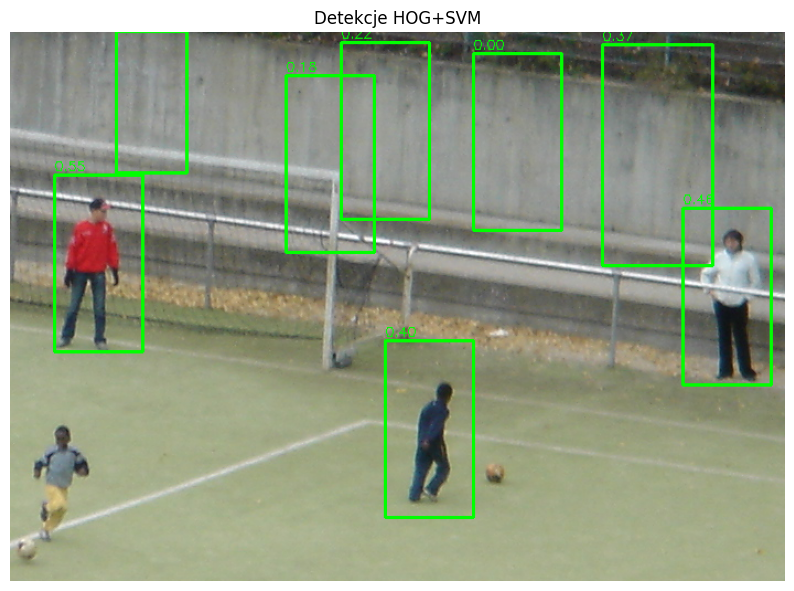

In [ ]:
img_path = '/content/gdrive/MyDrive/ZAW_lab11/Test images-pedestrians/testImage1.png'
orig_bgr = cv2.imread(img_path)

detections = detect_pedestrians(
    orig_bgr,
    clf=clf,
    step=8,
    scale_stride=1.25,
    threshold=0.0,
    nms_thresh=0.3)

print(f'Wykryto {len(detections)} sylwetek.')

vis = orig_bgr.copy()
for (x, y, w, h, score) in detections:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(vis, f'{score:.2f}', (x, y - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Detekcje HOG+SVM')
plt.show()


Wykryto 2 sylwetek (różne rozmiary).


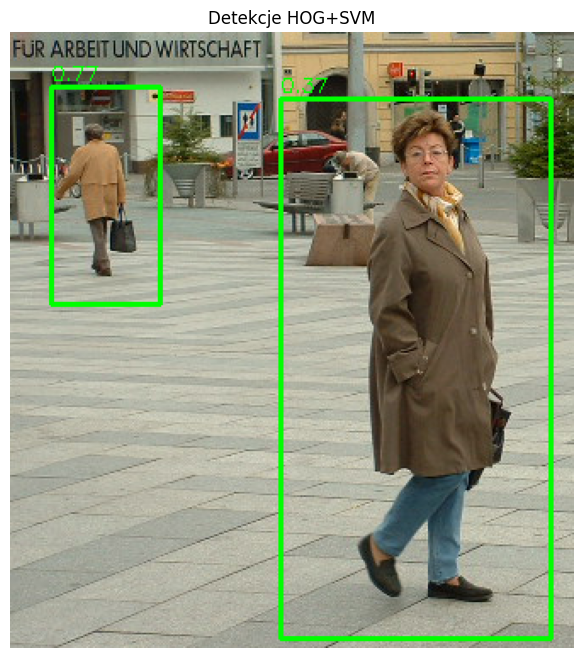

In [ ]:
img_path = '/content/gdrive/MyDrive/ZAW_lab11/Test images-pedestrians/testImage4.png'
orig_bgr = cv2.imread(img_path)

detections = detect_pedestrians(
    orig_bgr,
    clf,
    step=8,
    scale_stride=1.2,
    threshold=0.2,
    nms_thresh=0.3)

print(f'Wykryto {len(detections)} sylwetek (różne rozmiary).')
vis = orig_bgr.copy()
for (x, y, w, h, score) in detections:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(vis, f'{score:.2f}', (x, y - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Detekcje HOG+SVM')
plt.show()

